## TLab IV - Exploratory Data Analysis
### Predicting Daily Citi Bike Ridership
Hudson Mobility Analytics - Exploring the daily ridership + weather dataset built in Part 1 (TLab III), before cleaning and modeling.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
print(os.getcwd())
df = pd.read_csv("../data/citibike_weather_daily.csv")
print(df.shape)
print(df.shape)
df.head()

/workspaces/TLabs/TSQL3RidershipAnalysis/code
(1610, 10)
(1610, 10)


,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month
0,2013-07-01,16650,16.309988,74.8,78.1,73.4,7.8,0.00,Monday,7
1,2013-07-02,22745,15.968826,76.1,82.9,73.0,8.0,0.73,Tuesday,7
2,2013-07-03,21864,16.238808,78.5,84.9,73.9,8.8,0.06,Wednesday,7
3,2013-07-04,22326,21.218474,82.0,91.0,73.9,8.6,0.96,Thursday,7
4,2013-07-05,21842,18.040443,84.4,93.0,75.9,9.0,0.00,Friday,7


In [6]:
df.dtypes

ride_date               str
num_rides             int64
avg_duration_min    float64
temp_f              float64
max_temp_f          float64
min_temp_f          float64
wind_speed_knots    float64
precip_in           float64
day_of_week             str
month                 int64
dtype: object

### E1 Findings
`df.dtypes` confirms all columns loaded with the expected type <b>except</b> `ride_date`**, which pandas loaded as a string/object rather than a proper date type.


In [7]:
df.describe()

,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,month
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,32986.783230,15.425627,57.368509,67.317081,49.295901,9.013913,0.178398,6.544099
std,16910.147968,3.652633,17.876211,18.349408,17.832318,3.241211,2.508762,3.323772
min,876.000000,9.495396,8.300000,18.000000,1.000000,2.300000,0.000000,1.000000
25%,20505.500000,13.112342,43.625000,53.700000,35.700000,6.700000,0.000000,4.000000
50%,32272.500000,14.860057,59.300000,70.000000,51.100000,8.500000,0.000000,7.000000
75%,42915.750000,17.121551,73.500000,82.900000,64.900000,10.800000,0.060000,9.000000
max,78458.000000,81.110084,92.500000,100.900000,82.900000,22.400000,99.990000,12.000000


***E2 Findings
`describe()` reveals one clear data quality issue: **`precip_in` has a max value of 99.99**, which matches NOAA's documented sentinel code for missing precipitation observation (per the GSOD documentation). This is not real precipitation data - it needs to be treated as missing (NaN) in preprocessing.
Temperature and wind speed columns show no sentinel valus (9999.9, 999.9) and fall within physically plausible ranges for the NY area. `avg_duration_min` has a wide spread (9.5-81min), worth wathcing but we have to see.

In [8]:
(df['precip_in'] == 99.99).sum()

np.int64(1)

ONly <b>1 row</b> out of 1,610 has the `prcip_in = 99.99` sentinel - a small, easily handles fix in preprocessing.

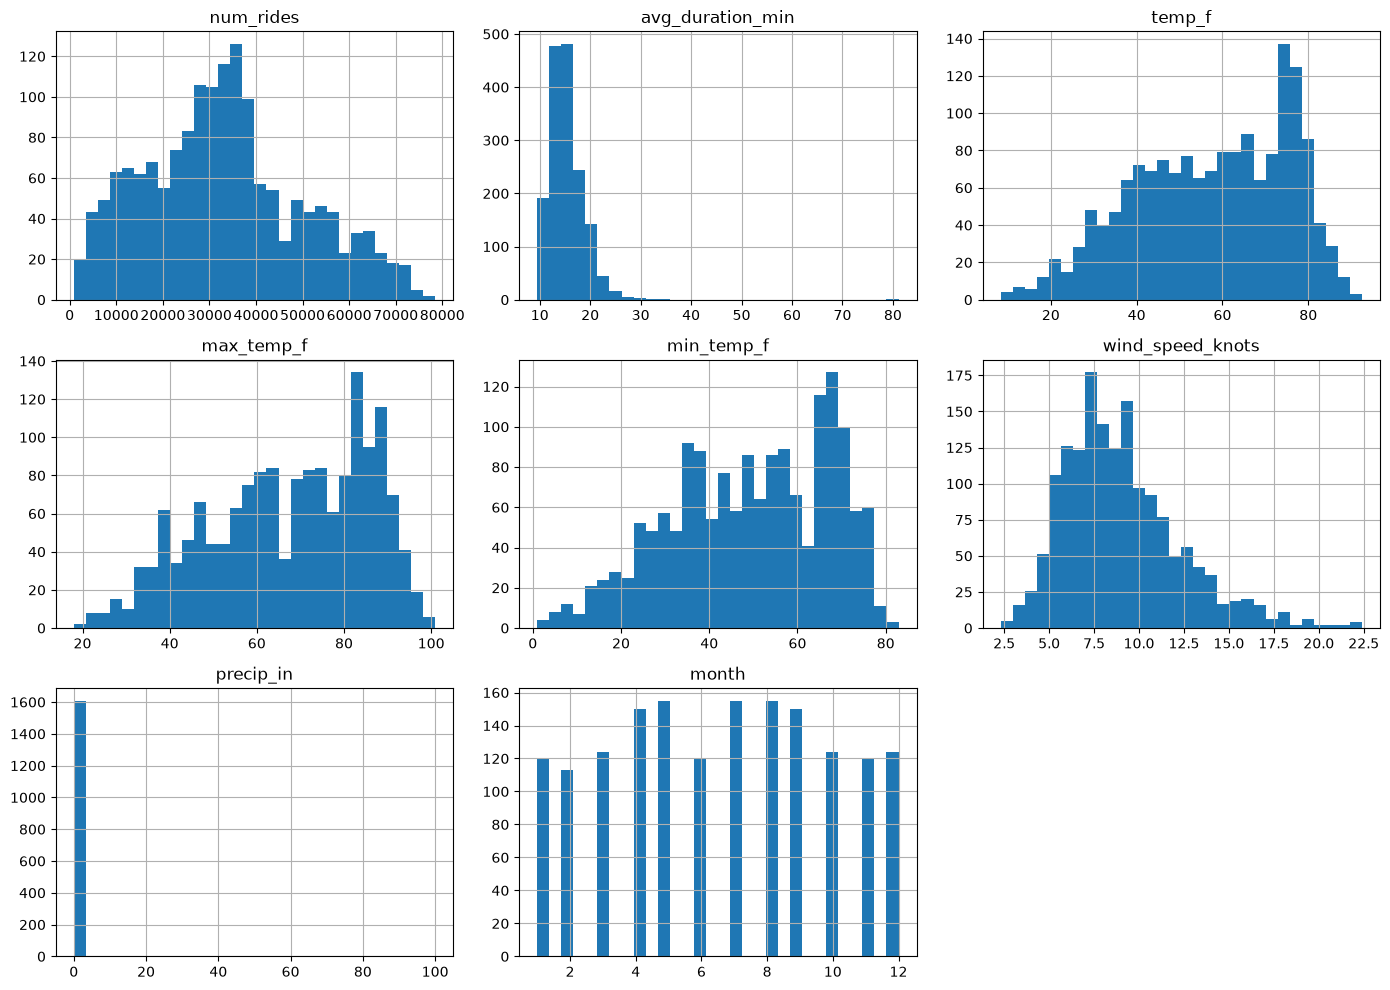

In [9]:
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

Histogram confirms most distributions look reasonable. 'preip_in' is heavily right-skewed toward 0 (most days have no rain), consistent with real precipitation data. No other columns show obvious spikes

***E3: Relationships With the Target - scatter plots vs. num_rides

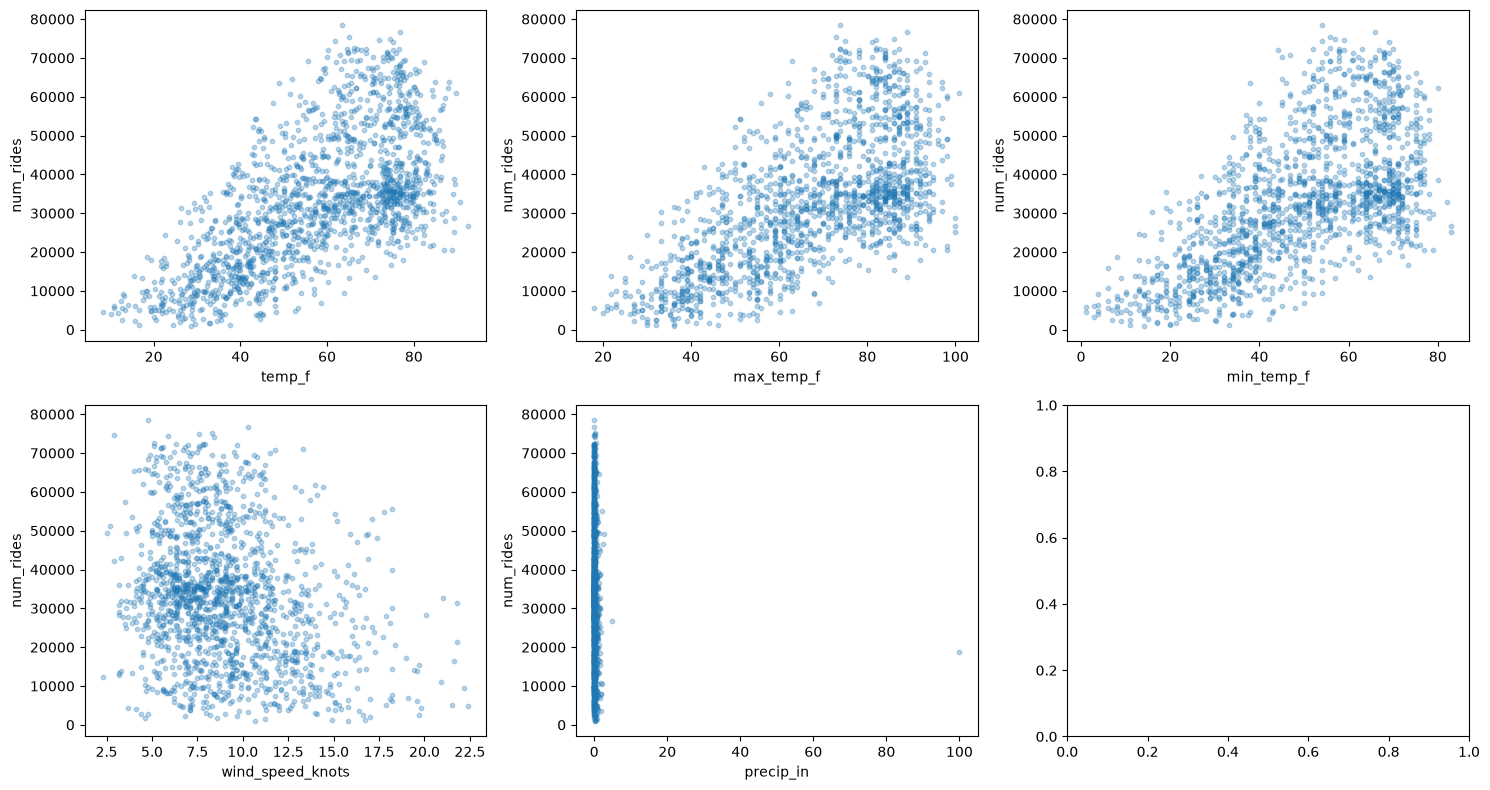

In [10]:
weather_cols = ['temp_f', 'max_temp_f', 'min_temp_f', 'wind_speed_knots', 'precip_in']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, weather_cols):
  ax.scatter(df[col], df['num_rides'], alpha=0.3, s=10)
  ax.set_xlabel(col)
  ax.set_ylabel('num_rides')
plt.tight_layout()
plt.show()

### E3 Findings
Temperature (temp_f, max_temp_f, min_temp_f) shows the strongest relationship with ridership - rides climb steadily with warmer weather up to roughly 70-75°F, then flatten or slightly decline at the hottest temps (80-90°F+). This suggests the relationship isn't purely linear - very hot days may suppress ridership rather than boost it further (a "comfort ceiling"). This hints that a squared temperature term (C5)could help a linear model capture this curve.
Wind speed shows a weak/scattered relationship. Precipitation's plot clearly shows the 99.99 sentinel value as an isolated outlier point, visually confirming the E2 finding.

##E4: Ridership Over Time:

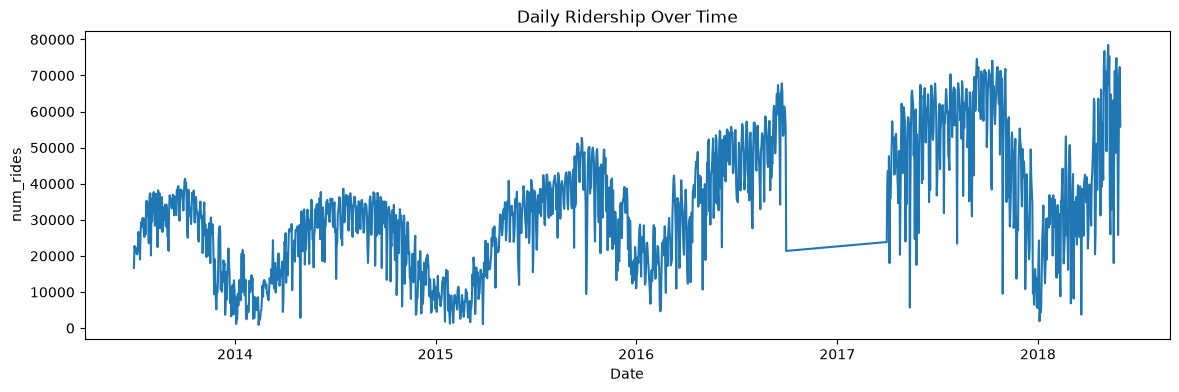

In [11]:
df['ride_date'] = pd.to_datetime(df['ride_date'])
plt.figure(figsize=(14, 4))
plt.plot(df['ride_date'], df['num_rides'])
plt.xlabel('Date')
plt.ylabel('num_rides')
plt.title('Daily Ridership Over Time')
plt.show()

### E4 Finding
- Clear seasonal pattern: ridership peaks each summer, drops in winter, every year 
- **Upward trend across year** - 2018's peaks are higher than 2013's (system growth)
- Flat line -late 2016/early 2017 = gap in data (see E6)
- July 2017 ≠ July 2013 at the same weather - model needs a trend feature to "know what year it is" 

In [12]:
df['year'] = df['ride_date'].dt.year
july = df[df['ride_date'].dt.month == 7]
july.groupby('year')['num_rides'].mean()

year
2013    27206.967742
2014    31252.967742
2015    35021.806452
2016    44519.677419
2017    55987.064516
Name: num_rides, dtype: float64

Clear, steady growth every year
- 2013: ~27,200 > 2017:~56,000; ridership has nearly doubled in 5 years
- Same July weather, very different ridership - confirms need for trend features


###E5: The Weekly Rhythm

In [15]:
df.groupby('day_of_week')['num_rides'].mean().sort_values()

day_of_week
Sunday       27260.650655
Saturday     28562.554585
Monday       33296.830435
Friday       34229.373913
Tuesday      35485.243478
Thursday     35737.753247
Wednesday    36264.731602
Name: num_rides, dtype: float64

### E5 Findings
-  Weekdays (Tue_Thu ~35K-36K busier than weekends (Sat/Sun ~27-28K)
- Matches intuition: Citi BIke used mainly for commuting, not weekend leisure
- Mon-Fri slightly lower than Tue-Thu. Could be attributed to remote/flex days

##E6: The Missing Day:
Checking how many dates are missing and where

In [16]:
full_range = pd.date_range(df['ride_date'].min(), df['ride_date'].max())
missing = full_range.difference(df['ride_date'])
print(len(missing))
missing

186


DatetimeIndex(['2016-01-23', '2016-01-24', '2016-01-25', '2016-01-26',
               '2016-10-01', '2016-10-02', '2016-10-03', '2016-10-04',
               '2016-10-05', '2016-10-06',
               ...
               '2017-03-22', '2017-03-23', '2017-03-24', '2017-03-25',
               '2017-03-26', '2017-03-27', '2017-03-28', '2017-03-29',
               '2017-03-30', '2017-03-31'],
              dtype='datetime64[us]', length=186, freq=None)

### E6 Findings
- 186 missing dates out of full date range
- Cluster: Oct 2016 - Mar 2017 (~5-6 month gap) - matches flat line seen in E4
- Small gap also Jan 2016 (23rd-26th)
- Hypothesis: LaGuardia weather station had missing observations this period > INNER JOIN in Part 1 dropped these ride days since weather was unmatched (gap came from weather side, not ride side)